<a href="https://colab.research.google.com/github/charlesembo99/charlesembo99/blob/master/cs_da02_25013_Classification_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [ ]:
# Load the dataset and convert to DataFrame
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

In [ ]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# DataFrame to store results
results = pd.DataFrame(columns=['Model', 'Accuracy'])


In [ ]:
# Helper function for confusion matrix plotting
def plot_conf_matrix(y_true, y_pred, class_names=None, title="Confusion Matrix", figsize=(6, 5)):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names if class_names is not None else "auto",
        yticklabels=class_names if class_names is not None else "auto"
    )

    plt.xlabel("Predicted Labels")
    plt.ylabel("Actual Labels")
    plt.title(title)
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
               precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.95      1.00      0.98        21
           2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



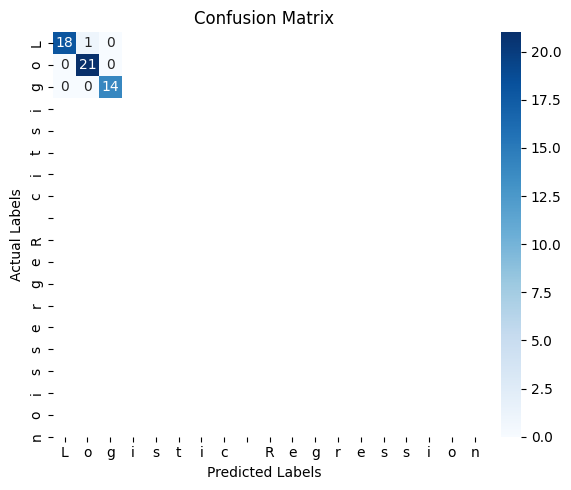

In [ ]:
# Train & evaluate models
## 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression\n", classification_report(y_test, y_pred_lr))
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")
results.loc[len(results)] = ['Logistic Regression', accuracy_score(y_test, y_pred_lr)]

Support Vector Machine (SVM)
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.63      0.90      0.75        21
           2       0.60      0.21      0.32        14

    accuracy                           0.76        54
   macro avg       0.74      0.71      0.69        54
weighted avg       0.75      0.76      0.72        54



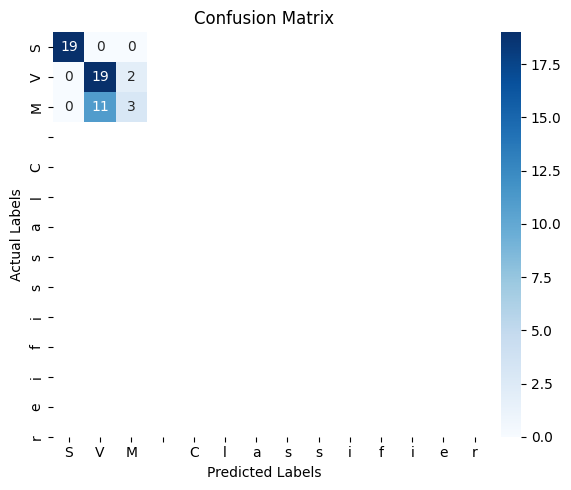

In [ ]:


## 2. Support Vector Machine (SVM)
svm_clf = SVC(kernel='rbf', C=1, gamma='scale')
svm_clf.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_clf.predict(X_test)

# Classification Report
print("Support Vector Machine (SVM)\n", classification_report(y_test, y_pred_svm))

# Confusion Matrix
plot_conf_matrix(y_test, y_pred_svm, "SVM Classifier")

# Store results
results.loc[len(results)] = ['SVM', accuracy_score(y_test, y_pred_svm)]


K-Nearest Neighbors (KNN)
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.75      0.71      0.73        21
           2       0.53      0.57      0.55        14

    accuracy                           0.74        54
   macro avg       0.73      0.73      0.73        54
weighted avg       0.74      0.74      0.74        54



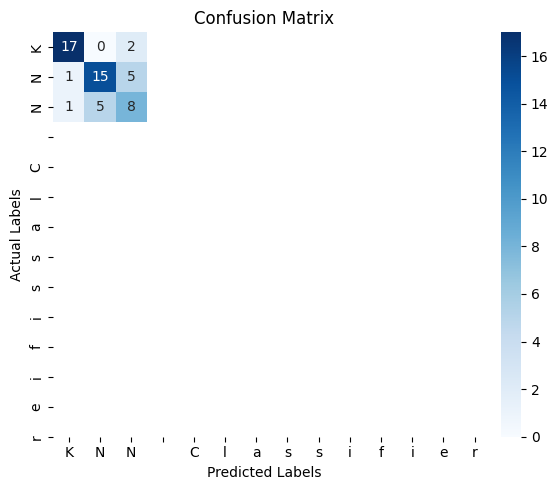

In [ ]:

# 3. K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

# Classification Report
print("K-Nearest Neighbors (KNN)\n", classification_report(y_test, y_pred_knn))

# Confusion Matrix
plot_conf_matrix(y_test, y_pred_knn, "KNN Classifier")

# Store results
results.loc[len(results)] = ['KNN', accuracy_score(y_test, y_pred_knn)]


Random Forest Classifier
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



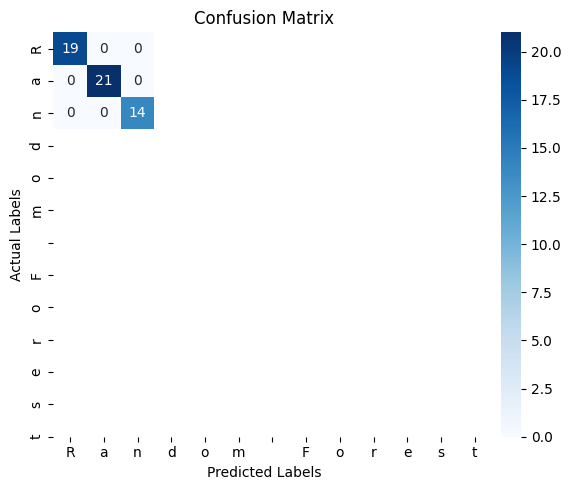

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 4. Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Classification Report
print("Random Forest Classifier\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
plot_conf_matrix(y_test, y_pred_rf, "Random Forest")

# Store results
results.loc[len(results)] = ['Random Forest', accuracy_score(y_test, y_pred_rf)]


Decision Tree Classifier
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



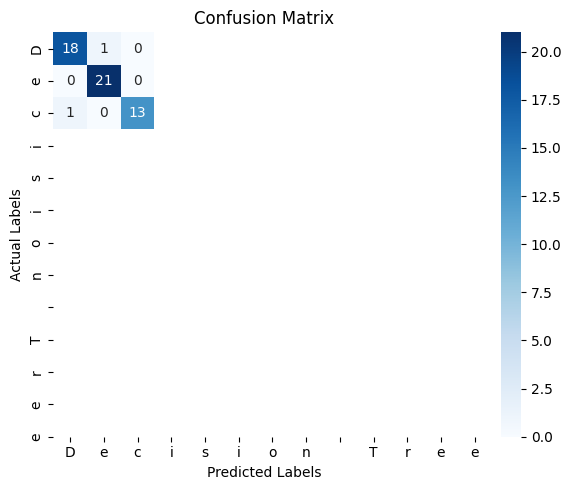

In [ ]:


# 5. Decision Tree Classifier
dt = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Classification Report
print("Decision Tree Classifier\n", classification_report(y_test, y_pred_dt))

# Confusion Matrix
plot_conf_matrix(y_test, y_pred_dt, "Decision Tree")

# Store results
results.loc[len(results)] = ['Decision Tree', accuracy_score(y_test, y_pred_dt)]


Gaussian Naive Bayes
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



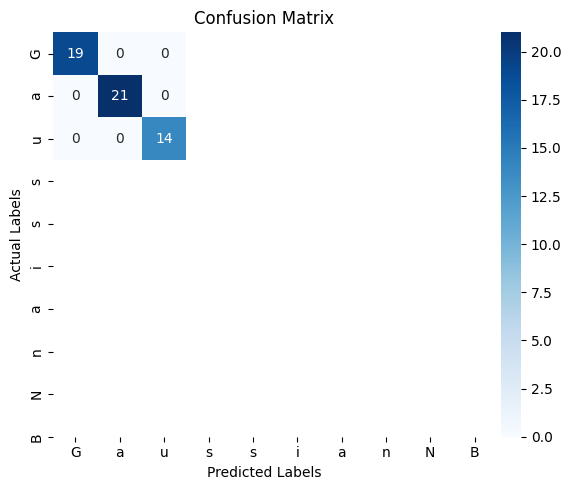

In [ ]:

# 6. Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predictions
y_pred_gnb = gnb.predict(X_test)

# Classification Report
print("Gaussian Naive Bayes\n", classification_report(y_test, y_pred_gnb))

# Confusion Matrix
plot_conf_matrix(y_test, y_pred_gnb, "GaussianNB")

# Store results
results.loc[len(results)] = ['GaussianNB', accuracy_score(y_test, y_pred_gnb)]


Linear Regression (continuous prediction):
MSE: 0.060, R²: 0.901, Accuracy (rounded): 0.944


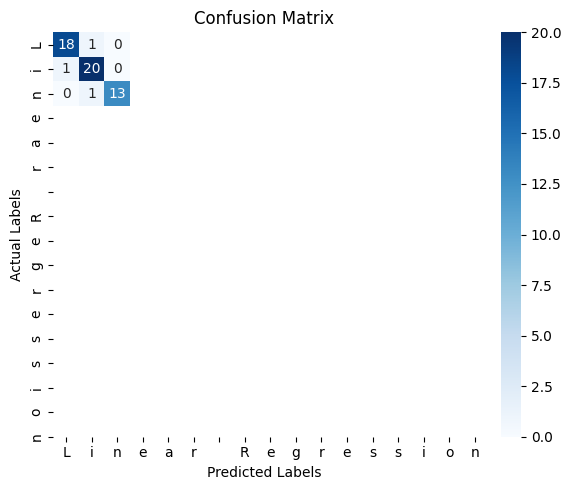

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# 7. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr_cont = lr_model.predict(X_test)

# Since predictions are continuous, round to nearest class for classification comparison
y_pred_lr_class = [round(val) for val in y_pred_lr_cont]

# Evaluation
mse = mean_squared_error(y_test, y_pred_lr_cont)
r2 = r2_score(y_test, y_pred_lr_cont)
accuracy = accuracy_score(y_test, y_pred_lr_class)

print(f"Linear Regression (continuous prediction):\nMSE: {mse:.3f}, R²: {r2:.3f}, Accuracy (rounded): {accuracy:.3f}")

# Confusion Matrix
plot_conf_matrix(y_test, y_pred_lr_class, "Linear Regression")

# Store results
results.loc[len(results)] = ['Linear Regression', accuracy]